## Carregando o dataset

In [1]:
%ls

data/  notebook.ipynb  notebook_sara.ipynb


In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)

# Carregar os datasets
df_treino = pd.read_csv('data/dados_treino.csv')
df_teste = pd.read_csv('data/dados_teste.csv')
print(f"Dimensões dataset treino:{df_treino.shape}")
print(f"Dimensões dataset teste:{df_teste.shape}")

Dimensões dataset treino:(16800, 42)
Dimensões dataset teste:(4200, 42)


In [3]:
df_treino = df_treino.drop("Unnamed: 0", axis = 1)
df_teste = df_teste.drop("Unnamed: 0", axis = 1)

In [4]:
df_teste.head()

,NU_ANO,NU_CONTATO,NU_COMU_EX,IDADE_ANOS,TEMPO_DE_NOTI,TEMPO_DE_INICIO_TRATAMENTO,CS_SEXO_F,CS_SEXO_M,CS_RACA_1,CS_RACA_2,CS_RACA_4,FORMA_1,FORMA_2,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,TRATSUP_AT_1.0,TRATSUP_AT_2.0,POP_LIBER_1.0,POP_LIBER_2.0,BENEF_GOV_1.0,BENEF_GOV_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVTABAC_1,AGRAVTABAC_2,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3,SITUACAO_AGRUPADA
0,2023,0.0,0.0,33,1560,1507.0,True,False,False,False,True,True,False,False,True,True,False,False,True,True,False,False,True,False,True,False,True,True,False,True,False,True,False,False,False,False,True,False,False,False,1
1,2023,1.0,1.0,35,33,2.0,False,True,False,False,True,True,False,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False,0
2,2023,4.0,4.0,29,0,0.0,True,False,False,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,True,False,False,True,False,0
3,2023,0.0,0.0,29,0,0.0,False,True,False,False,True,True,False,False,True,False,True,False,True,False,True,False,True,True,False,False,True,False,True,True,False,False,False,False,True,False,True,False,False,False,0
4,2023,2.0,2.0,31,0,1.0,False,True,False,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,False,True,False,False,False,False,True,False,0


### Separação de variáveis

Para o treinamento do modelo, as colunas dos datasets foram separadas em quatro grupos:

- **Variáveis de Ano**: Sinaliza o Ano da amostra.
- **Variáveis Regressivas**: variáveis contínuas ou numéricas utilizadas como preditores principais.
- **Variável Alvo**: variável que será prevista pelo modelo. Neste caso, `SITUACAO_AGRUPADA`.
- **Variáveis Classificativas**: variáveis categóricas já na forma de one-hot

In [5]:
col_anual = ["NU_ANO"]
col_regressivas = ["NU_CONTATO", "IDADE_ANOS", "TEMPO_DE_NOTI", "TEMPO_DE_INICIO_TRATAMENTO"]
col_alvo = "SITUACAO_AGRUPADA"
col_classificativas = [col for col in df_treino.columns if col not in col_regressivas + [col_alvo]]

### Verificando se há interseção entre colunas:

In [6]:
# Transforma tudo em conjuntos
regressivas = set(col_regressivas)
classificativas = set(col_classificativas)
todas_colunas = set(df_treino.columns)
target_set = {col_alvo}

# Testa se não há interseção
sem_interseção = regressivas.isdisjoint(classificativas)

# Testa se a união cobre todas as colunas (exceto o col_alvo)
cobre_tudo = regressivas.union(classificativas, target_set) == todas_colunas

# Resultado final
if sem_interseção and cobre_tudo:
    print("Tudo certo: sem interseção e todas as colunas cobertas.")
else:
    print("Há sobreposição ou colunas faltando.")


Tudo certo: sem interseção e todas as colunas cobertas.


### Verificando se os datasets têm colunas iguais

In [7]:
df_treino.columns.equals(df_teste.columns)

True

## Lidando com dados ausentes

### Procurando as colunas com valores nulos

Porcentagem de valores nulos no treino (%):
NU_ANO                        0.00
NU_CONTATO                    0.90
NU_COMU_EX                    4.26
IDADE_ANOS                    0.00
TEMPO_DE_NOTI                 0.00
TEMPO_DE_INICIO_TRATAMENTO    1.99
CS_SEXO_F                     0.00
CS_SEXO_M                     0.00
CS_RACA_1                     0.00
CS_RACA_2                     0.00
CS_RACA_4                     0.00
FORMA_1                       0.00
FORMA_2                       0.00
AGRAVAIDS_1.0                 0.00
AGRAVAIDS_2.0                 0.00
AGRAVALCOO_1.0                0.00
AGRAVALCOO_2.0                0.00
AGRAVDIABE_1.0                0.00
AGRAVDIABE_2.0                0.00
AGRAVOUTRA_1.0                0.00
AGRAVOUTRA_2.0                0.00
TRATSUP_AT_1.0                0.00
TRATSUP_AT_2.0                0.00
POP_LIBER_1.0                 0.00
POP_LIBER_2.0                 0.00
BENEF_GOV_1.0                 0.00
BENEF_GOV_2.0                 0.00
AGRAVDROGA_

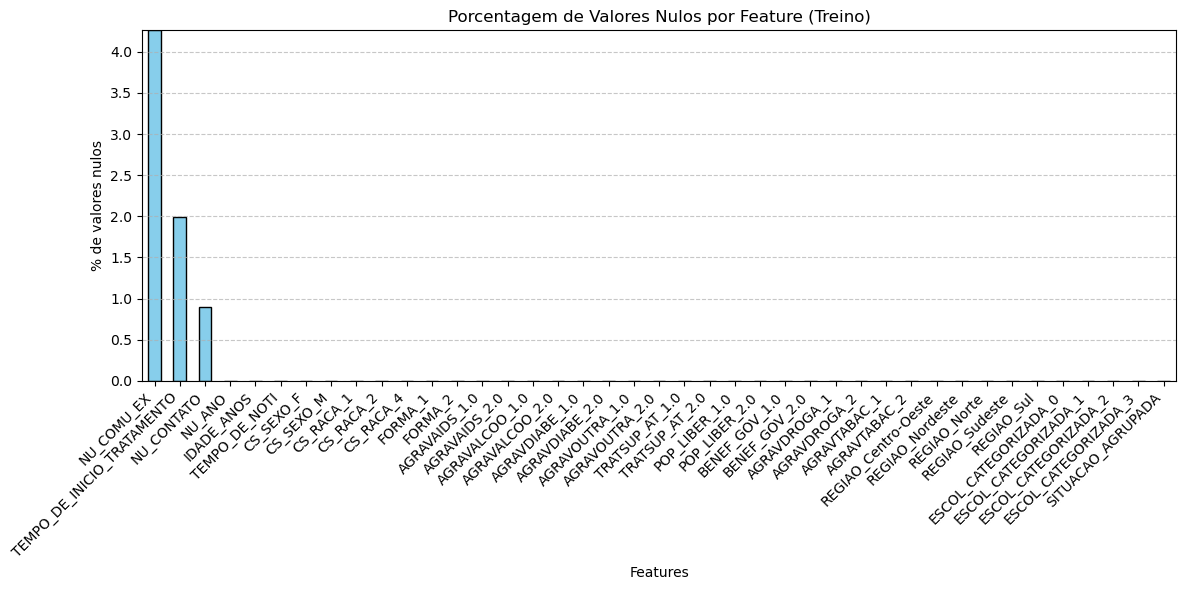

In [8]:
import matplotlib.pyplot as plt

# Percentual de valores nulos no dataset de treino
print("Porcentagem de valores nulos no treino (%):")
print((df_treino.isnull().sum() / len(df_treino) * 100).round(2))

# Percentual de valores nulos no dataset de teste
print("\nPorcentagem de valores nulos no teste (%):")
print((df_teste.isnull().sum() / len(df_teste) * 100).round(2))


# Plotando qtd de valores nulos
null_percent = (df_treino.isnull().sum() / len(df_treino) * 100).round(2)
null_percent = null_percent.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
null_percent.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Porcentagem de Valores Nulos por Feature (Treino)')
plt.ylabel('% de valores nulos')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(null_percent.max(), 1))  # Garantir alguma altura mínima visível
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Como todas as colunas apresentam **menos de 5% de valores faltantes**, **nenhuma será removida**. Em vez disso, optamos por **imputar os valores ausentes com base na estrutura dos dados**, de forma a preservar a informação e reduzir viés:

* **Features Classificativas:** preenchidas com a moda dos valores da feture dentre aquelas do mesmo grupo da `SITUACAO_AGRUPADA`.
* **Features Regressivas:** preenchidas com a média por grupo da feture dentre aquelas do mesmo grupo da `SITUACAO_AGRUPADA`.

> **Observação:** não há casos com valores nulos na variável alvo `SITUACAO_AGRUPADA`.


In [9]:
# Transformar classificações: True/False → 1/0 (sem alterar NaNs)
for col in col_classificativas:
    df_treino[col] = df_treino[col].apply(lambda x: int(x) if pd.notnull(x) else x)
    df_teste[col] = df_teste[col].apply(lambda x: int(x) if pd.notnull(x) else x)

# Transformar colunas de regressão: int → float (sem alterar NaNs)
for col in col_regressivas:
    df_treino[col] = df_treino[col].astype(float)
    df_teste[col] = df_teste[col].astype(float)

# Obter a lista de colunas com valores nulos
colunas_com_nulos = df_treino.columns[df_treino.isnull().any()].tolist()

for col in colunas_com_nulos:
    if col in col_classificativas:  # Coluna categórica (binária)
        modos = df_treino.groupby('SITUACAO_AGRUPADA')[col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 0)
        df_treino[col] = df_treino.apply(
            lambda row: modos[row['SITUACAO_AGRUPADA']] if pd.isnull(row[col]) else row[col], axis=1
        )
        df_teste[col] = df_teste.apply(
            lambda row: modos.get(row['SITUACAO_AGRUPADA'], 0) if pd.isnull(row[col]) else row[col], axis=1
        )

    elif col in col_regressivas:  # Coluna numérica (regressiva)
        medias = df_treino.groupby('SITUACAO_AGRUPADA')[col].mean()
        media_global = df_treino[col].mean()
        df_treino[col] = df_treino.apply(
            lambda row: medias[row['SITUACAO_AGRUPADA']] if pd.isnull(row[col]) else row[col], axis=1
        )
        df_teste[col] = df_teste.apply(
            lambda row: medias.get(row['SITUACAO_AGRUPADA'], media_global) if pd.isnull(row[col]) else row[col], axis=1
        )


In [10]:
# Percentual de valores nulos no dataset de treino
print("Porcentagem de valores nulos no treino (%):")
print((df_treino.isnull().sum() / len(df_treino) * 100).round(2))

# Percentual de valores nulos no dataset de teste
print("\nPorcentagem de valores nulos no teste (%):")
print((df_teste.isnull().sum() / len(df_teste) * 100).round(2))

Porcentagem de valores nulos no treino (%):
NU_ANO                        0.0
NU_CONTATO                    0.0
NU_COMU_EX                    0.0
IDADE_ANOS                    0.0
TEMPO_DE_NOTI                 0.0
TEMPO_DE_INICIO_TRATAMENTO    0.0
CS_SEXO_F                     0.0
CS_SEXO_M                     0.0
CS_RACA_1                     0.0
CS_RACA_2                     0.0
CS_RACA_4                     0.0
FORMA_1                       0.0
FORMA_2                       0.0
AGRAVAIDS_1.0                 0.0
AGRAVAIDS_2.0                 0.0
AGRAVALCOO_1.0                0.0
AGRAVALCOO_2.0                0.0
AGRAVDIABE_1.0                0.0
AGRAVDIABE_2.0                0.0
AGRAVOUTRA_1.0                0.0
AGRAVOUTRA_2.0                0.0
TRATSUP_AT_1.0                0.0
TRATSUP_AT_2.0                0.0
POP_LIBER_1.0                 0.0
POP_LIBER_2.0                 0.0
BENEF_GOV_1.0                 0.0
BENEF_GOV_2.0                 0.0
AGRAVDROGA_1                  0.0
AGRA

## Separação da variável alvo do restante dos dados de treino e teste

Agora, vamos separar os datasets de treino e teste (`df_treino` e `df_teste`) em duas partes: as colunas de entrada para a predição (`X_treino` e `X_teste`) e as variáveis-alvo para avaliação (`y_treino` e `y_teste`)."

In [11]:
X_treino = df_treino.drop(columns=[col_alvo])
y_treino = df_treino[col_alvo]

X_teste = df_teste.drop(columns=[col_alvo])
y_teste = df_teste[col_alvo]

In [12]:
X_treino.head()

,NU_ANO,NU_CONTATO,NU_COMU_EX,IDADE_ANOS,TEMPO_DE_NOTI,TEMPO_DE_INICIO_TRATAMENTO,CS_SEXO_F,CS_SEXO_M,CS_RACA_1,CS_RACA_2,CS_RACA_4,FORMA_1,FORMA_2,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,TRATSUP_AT_1.0,TRATSUP_AT_2.0,POP_LIBER_1.0,POP_LIBER_2.0,BENEF_GOV_1.0,BENEF_GOV_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVTABAC_1,AGRAVTABAC_2,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3
0,2019,1.0,0.0,24.0,10.0,11.0,0,1,0,0,1,1,0,1,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0
1,2020,3.0,3.0,36.0,67.0,19.0,0,1,0,0,1,0,1,0,1,1,0,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,1,0,1,0,0,0
2,2021,5.0,5.0,61.0,1.0,3.0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0
3,2019,2.0,1.0,57.0,1.0,1.0,0,1,0,0,1,1,0,0,1,0,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,1,0,1,0,0,0
4,2020,14.0,14.0,24.0,0.0,0.0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,1,1,0,1,0,0,1,1,0,1,0,0,0,1,0,0,1,0,0,0


In [13]:
print("X_treino shape:", X_treino.shape)
print("y_treino shape:", y_treino.shape)
print("X_teste shape:", X_teste.shape)
print("y_teste shape:", y_teste.shape)


X_treino shape: (16800, 40)
y_treino shape: (16800,)
X_teste shape: (4200, 40)
y_teste shape: (4200,)


### Investigando desbalanceamento de classes

Fomos orientados a procurar resolver o problema de desbalanceamento de classes quando `n_maj > 1.5⋅n_min`

In [14]:
from collections import Counter

# Conta as amostras por classe no y_treino
classe_counts = Counter(y_treino)
n_maj = max(classe_counts.values())
n_min = min(classe_counts.values())

# Verifica a condição
desbalanceado = n_maj > 1.5 * n_min
print(f"Desbalanceado? {desbalanceado} (n_maj = {n_maj}, n_min = {n_min})")

Desbalanceado? True (n_maj = 15136, n_min = 1664)


Como há esse desbalanceio na variável alvo no dataset de treinamento, devemos aplicar uma técnica de balanceamento de dados dentro da pipeline de treinamento a seguir:

## **Grid Search com Validação Temporal e Pipeline de Pré-processamento**


Utilizamos **validação cruzada com divisão temporal (time-based folds)** para encontrar os melhores hiperparâmetros do modelo informado, testando todas as combinações possíveis dos parâmetros especificados (**grid search**). A métrica usada para otimização foi o **`f1-score (classe 1)`**, pois ela equilibra **precisão e recall**, sendo especialmente útil em **problemas desbalanceados** nos quais tanto **falsos negativos quanto falsos positivos são relevantes**  (como no nosso caso, de predição de óbitos).

A validação respeita a ordem cronológica dos dados, simulando um cenário realista no qual o modelo é treinado com dados de anos anteriores e testado em dados mais recentes. Isso evita o **vazamento de informações futuras**, garantindo uma avaliação mais próxima da aplicação real do modelo.

---

#### Pipeline de Treinamento

A pipeline de avaliação e treinamento do modelo segue os seguintes passos:

1. **Normalização das Features**
   Utilizamos o `StandardScaler` para padronizar as variáveis com média 0 e desvio padrão 1. Essa etapa é fundamental para modelos sensíveis à escala das variáveis, garantindo que nenhuma feature domine o processo de aprendizado.

2. **Balanceamento com SMOTE (etapa facultativa)**
   Em alguns modelos, aplicamos a técnica `SMOTE` para gerar exemplos sintéticos da classe minoritária e lidar com o desbalanceamento. Entretanto, notamos que modelos como o `RandomForestClassifier` apresentaram melhor desempenho **sem SMOTE**, possivelmente devido à sensibilidade da floresta ao ruído introduzido nas fronteiras de decisão. Por isso, o uso de SMOTE foi deixado como **opcional**, dependendo do modelo avaliado.

3. **Treinamento do Modelo**
   O classificador (como `RandomForestClassifier`, `LogisticRegression`, `KNeighborsClassifier`, etc.) é treinado com os dados já normalizados (e balanceados, se aplicável), garantindo consistência na avaliação com a validação temporal e na busca dos melhores hiperparâmetros.


In [15]:
X_treino.head()

,NU_ANO,NU_CONTATO,NU_COMU_EX,IDADE_ANOS,TEMPO_DE_NOTI,TEMPO_DE_INICIO_TRATAMENTO,CS_SEXO_F,CS_SEXO_M,CS_RACA_1,CS_RACA_2,CS_RACA_4,FORMA_1,FORMA_2,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,TRATSUP_AT_1.0,TRATSUP_AT_2.0,POP_LIBER_1.0,POP_LIBER_2.0,BENEF_GOV_1.0,BENEF_GOV_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVTABAC_1,AGRAVTABAC_2,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3
0,2019,1.0,0.0,24.0,10.0,11.0,0,1,0,0,1,1,0,1,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0
1,2020,3.0,3.0,36.0,67.0,19.0,0,1,0,0,1,0,1,0,1,1,0,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,1,0,1,0,0,0
2,2021,5.0,5.0,61.0,1.0,3.0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0
3,2019,2.0,1.0,57.0,1.0,1.0,0,1,0,0,1,1,0,0,1,0,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,1,0,1,0,0,0
4,2020,14.0,14.0,24.0,0.0,0.0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,1,1,0,1,0,0,1,1,0,1,0,0,0,1,0,0,1,0,0,0


In [16]:
X_treino['NU_ANO'].value_counts()

NU_ANO
2019    4200
2020    4200
2021    4200
2022    4200
Name: count, dtype: int64

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from imblearn.pipeline import make_pipeline as make_pipeline_imblearn
from sklearn.pipeline import make_pipeline as make_pipeline_sklearn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Geração dos índices personalizados
def get_time_series_splits(X, y):
    anos = sorted(X['NU_ANO'].unique())
    splits = []

    for i in range(1, len(anos)):
        anos_treino = anos[:i]
        ano_teste = anos[i]

        idx_treino = X[X['NU_ANO'].isin(anos_treino)].index.values
        idx_teste  = X[X['NU_ANO'] == ano_teste].index.values

        splits.append((idx_treino, idx_teste))
    
    return splits

def treinar_com_melhores_parametros(modelo_base, params, nome, usar_smote=True):
    def criar_pipeline(modelo):
        if usar_smote:
            return ImbPipeline([
                ('smote', SMOTE(random_state=42)),
                ('scaler', StandardScaler()),
                ('modelo', modelo)
            ])
        else:
            return Pipeline([
                ('scaler', StandardScaler()),
                ('modelo', modelo)
            ])

    # Cria pipeline temporária só para pegar o nome do modelo
    temp_pipe = criar_pipeline(modelo_base)
    nome_modelo = temp_pipe.steps[-1][0]

    # Define os parâmetros para o GridSearch
    param_grid = {f"{nome_modelo}__{k}": v for k, v in params.items()}

    # Dados de treino para validação cruzada (sem o último ano)
    anos = sorted(X_treino['NU_ANO'].unique())
    ano_mais_recente = max(anos)
    X_cv = X_treino[X_treino['NU_ANO'] < ano_mais_recente].reset_index(drop=True)
    y_cv = y_treino.loc[X_cv.index].reset_index(drop=True)

    # GridSearchCV com validação temporal
    splits = get_time_series_splits(X_cv, y_cv)
    grid = GridSearchCV(
        criar_pipeline(modelo_base),
        param_grid,
        cv=splits,
        scoring=make_scorer(f1_score, pos_label=1),
        refit=True,
        n_jobs=-1
    )

    grid.fit(X_cv.drop(columns=['NU_ANO']), y_cv)

    best_params = grid.best_params_
    print(f"[GridSearchCV] {nome} — melhor f1_score_1: {grid.best_score_:.4f}")
    print(f"Hiperparâmetros ótimos: {best_params}")

    # Ajusta o modelo base com os melhores parâmetros
    modelo_tuned = modelo_base.set_params(**{
        k.replace(f"{nome_modelo}__", ""): v for k, v in best_params.items()
    })

    # Dados completos e sem o último ano
    X_todos_anos = X_treino.drop(columns=['NU_ANO'])
    y_todos_anos = y_treino

    X_sem_ultimo_ano = X_treino[X_treino['NU_ANO'] < ano_mais_recente].drop(columns=['NU_ANO'])
    y_sem_ultimo_ano = y_treino.loc[X_sem_ultimo_ano.index]

    # Pipelines finais já treinadas
    modelo_todos_anos = criar_pipeline(modelo_tuned)
    modelo_sem_ultimo_ano = criar_pipeline(modelo_tuned)

    modelo_todos_anos.fit(X_todos_anos, y_todos_anos)
    modelo_sem_ultimo_ano.fit(X_sem_ultimo_ano, y_sem_ultimo_ano)

    return modelo_todos_anos, modelo_sem_ultimo_ano, best_params, grid.best_score_

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
params_knn = {
    'n_neighbors': [1, 5, 10],
    'p': [1, 2],
    'weights': ['uniform', 'distance']
}

knn_best_todos_anos, knn_sem_ultimo_ano, best_params, score_knn = treinar_com_melhores_parametros(knn, params_knn, "kNN")

[GridSearchCV] kNN — melhor f1_score_1: 0.0916
Hiperparâmetros ótimos: {'modelo__n_neighbors': 1, 'modelo__p': 2, 'modelo__weights': 'uniform'}


In [19]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)
params_log = {
    'class_weight': ['balanced', {0: 2, 1: 3}]
}

log_todos_anos, log_sem_ultimo_ano, best_params, score_log  = treinar_com_melhores_parametros(log, params_log, "Regressão Logística")

[GridSearchCV] Regressão Logística — melhor f1_score_1: 0.0000
Hiperparâmetros ótimos: {'modelo__class_weight': 'balanced'}


Durante nossos experimentos percebemos que sem o `SMOTE` o `Random Forest` perfoma melhor, o que resolvemos adicionar a seguir no notebook final. Nosa hipótese é de  que estrutura do Random Forest, ao trabalhar com múltiplas árvores e amostragem aleatória, já oferece certa robustez contra o desbalanceamento, fazendo o com que o `SMOTE` seja desnecessário ou até enviese o modelo.
<br><br>
No `knn`e `CNN` não houve melhoras ao remover o `SMOTE` da pipeline

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
params_rf = {
    'n_estimators': [10, 100, 200],
    'max_depth': [10, 50],
    'min_samples_split': [2, 10, 30],
    'class_weight': ['balanced']
}
rf_todos_anos, rf_ultimo_ano, best_params, score_rf = treinar_com_melhores_parametros(rf, params_rf, "Random Forest")

[GridSearchCV] Random Forest — melhor f1_score_1: 0.0266
Hiperparâmetros ótimos: {'modelo__class_weight': 'balanced', 'modelo__max_depth': 50, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 10}


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
params_rf = {
    'n_estimators': [10, 100, 200],
    'max_depth': [10, 50],
    'min_samples_split': [2, 10, 30],
    'class_weight': ['balanced']
}
rf_wo_smote_todos_anos, rf_wo_smote_ultimo_ano, best_params, score_rf = treinar_com_melhores_parametros(rf, params_rf, "Random Forest", usar_smote=False)

[GridSearchCV] Random Forest — melhor f1_score_1: 0.1347
Hiperparâmetros ótimos: {'modelo__class_weight': 'balanced', 'modelo__max_depth': 10, 'modelo__min_samples_split': 10, 'modelo__n_estimators': 10}


Agora, após extrairmos os melhores hiperparâmetros para o `f1-score` máximo no cross validation de 4 modelos (`RandomForestClassifier com SMOTE`,  `RandomForestClassifier sem SMOTE`, `LogisticRegression`, `KNeighborsClassifier`), vamos avaliar os `recall` de cada modelo para variações do `treshold` deles, utilizando os modelos treinados nos dados de treinamento dos anos de 2019 a 2021 e validando pelos dados do ano de 2022. Assim avaliamos o **tradeoff de precision e recall** via passagem de treshold, com objetivo de selecionar o modelo que **tenha um recall mínimo** para nossa tarefa (seleiconamos para recall >= 0.8) e que, em compensação, também tenha a **melhor precision possível** dada a limitação citada do recall.

Perceba que selecionarmos os hiperparâmetros do modelo no grid-search via a métrica do `f1-score`,para com ele termos um treinamento que priorize um modelo **equiblibrado em recall e precision**, dado as propiedades da fórmula do `f1-score`. entretando na parte do ajuste fino do treshold nós iremos nivelar os modelos para o treshold mínimo tal que recall >= 0.8 porque queremos ter uma frequência pareada e razoável entre os modelos de casos com Falso Neagtivo, que são altamente preocupantes para nossa tarefa, pois representa a proporção de pessoas que iriam ao óbito mas o modelo havia indicado que iriam se curar. Então dando um recall fixo inegociável nós vamos a busca do modelo que tenha o melhor precision para conseguir também minimizar melhor os casos de Falsos Positivos, que não são da prioridade equivalente a minimizar os falsos negativos mas também são preocupantes e servirá de desempate.

In [22]:
def plot_metrics_vs_threshold_invertido(y_true, y_probs, recall_min=0.80):
    import numpy as np
    import matplotlib.pyplot as plt

    thresholds = np.arange(0.00, 1.02, 0.01)
    precision_list = []
    recall_list = []
    f1_list = []

    for thresh in thresholds:
        preds = (y_probs >= thresh).astype(int)
        tp = ((preds == 1) & (y_true == 1)).sum()
        fp = ((preds == 1) & (y_true == 0)).sum()
        fn = ((preds == 0) & (y_true == 1)).sum()

        precision = tp / (tp + fp + 1e-10)
        recall = tp / (tp + fn + 1e-10)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    # Plotando as curvas
    plt.figure(figsize=(12, 6))
    plt.plot(thresholds, precision_list, label='Precisão', marker='o')
    plt.plot(thresholds, recall_list, label='Recall', marker='o')
    plt.plot(thresholds, f1_list, label='F1 Score', marker='o')
    plt.xlabel('Threshold')
    plt.ylabel('Métrica')
    plt.title('Métricas por Threshold')
    plt.xticks(np.arange(0.00, 1.01, 0.05))
    plt.yticks(np.arange(0.00, 1.01, 0.1))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Encontrar o threshold com MENOR recall >= recall_min (ou seja, maior threshold possível que ainda satisfaz a condição)
    for thresh, prec, rec, f1 in zip(thresholds[::-1], precision_list[::-1], recall_list[::-1], f1_list[::-1]):
        if rec >= recall_min:
            return {
                "threshold": thresh,
                "precision": prec,
                "recall": rec,
                "f1_score": f1
            }

In [23]:
y_val = y_treino[X_treino['NU_ANO'] == X_treino['NU_ANO'].max()]
X_val = X_treino[X_treino['NU_ANO'] == X_treino['NU_ANO'].max()].drop(columns=['NU_ANO'])

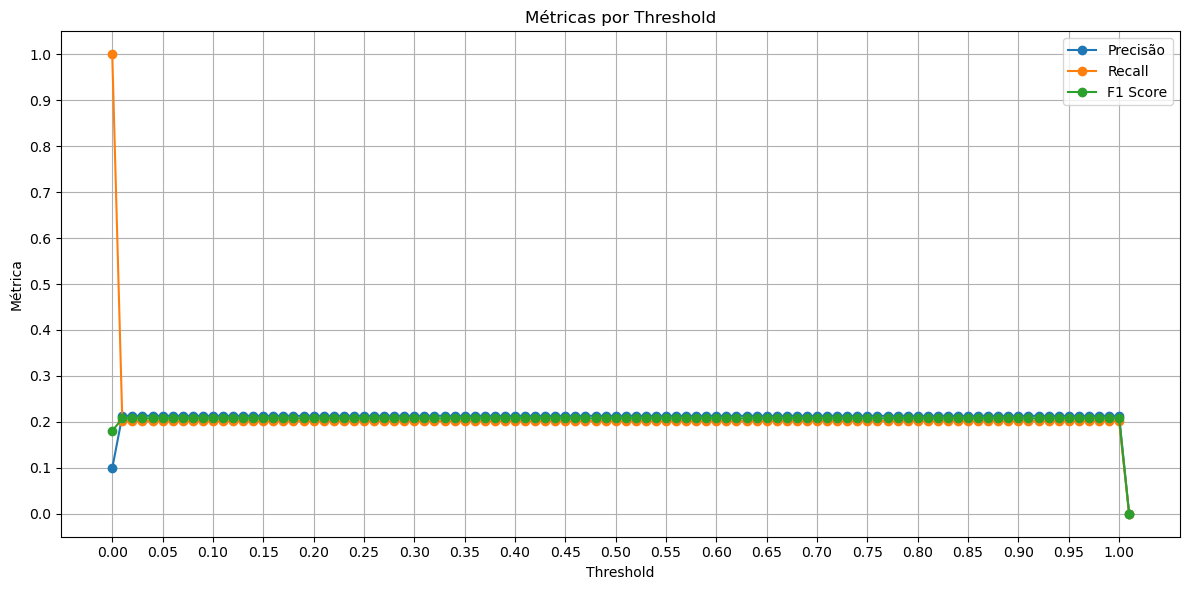

{'threshold': np.float64(0.0),
 'precision': np.float64(0.09904761904761669),
 'recall': np.float64(0.9999999999997596),
 'f1_score': np.float64(0.1802426342990169)}

In [24]:

melhor_threshold_info = plot_metrics_vs_threshold_invertido(y_val, knn_sem_ultimo_ano.predict_proba(X_val)[:, 1])
melhor_threshold_info

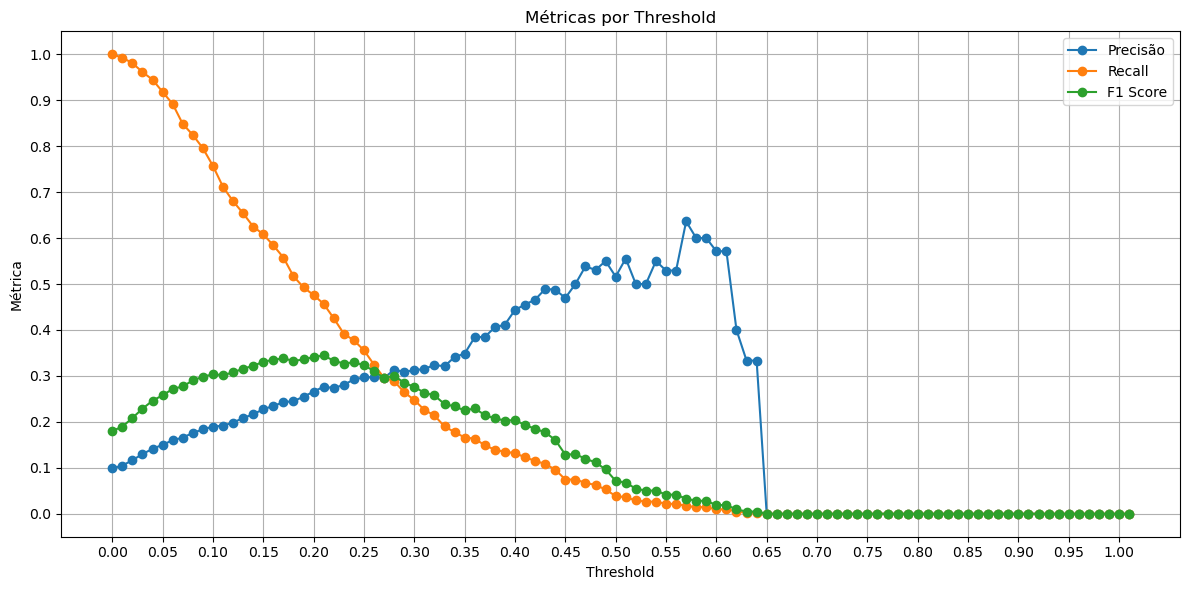

{'threshold': np.float64(0.08),
 'precision': np.float64(0.17598768599280779),
 'recall': np.float64(0.8245192307690326),
 'f1_score': np.float64(0.29006342491812964)}

In [25]:
melhor_threshold_info = plot_metrics_vs_threshold_invertido(y_val, log_sem_ultimo_ano.predict_proba(X_val)[:, 1])
melhor_threshold_info

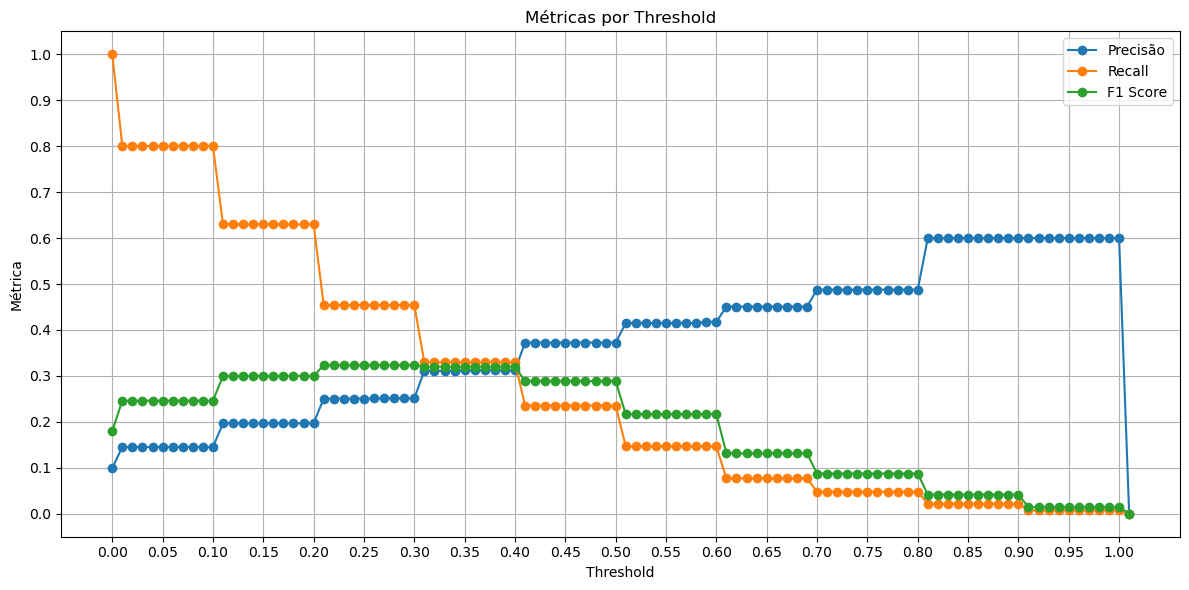

{'threshold': np.float64(0.1),
 'precision': np.float64(0.1454148471615657),
 'recall': np.float64(0.8004807692305769),
 'f1_score': np.float64(0.246119733898574)}

In [26]:
melhor_threshold_info = plot_metrics_vs_threshold_invertido(y_val, rf_ultimo_ano.predict_proba(X_val)[:, 1])
melhor_threshold_info

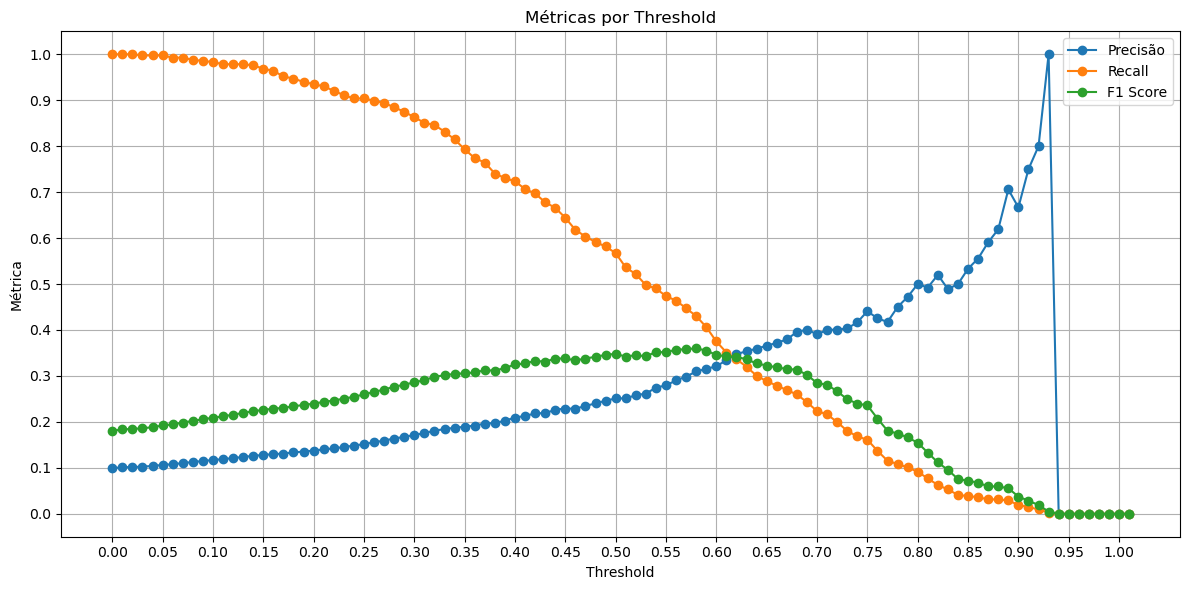

{'threshold': np.float64(0.34),
 'precision': np.float64(0.18718939812257387),
 'recall': np.float64(0.8149038461536503),
 'f1_score': np.float64(0.3044454422686487)}

In [27]:
melhor_threshold_info = plot_metrics_vs_threshold_invertido(y_val, rf_wo_smote_ultimo_ano.predict_proba(X_val)[:, 1])
melhor_threshold_info

O resultado mais interessante é o de `Random Forest sem SMOTE`, pois tem, para certo treshold (0.34), teve o `recall` que procuramos (0.8149>=0.8) e com uma `precision` melhor que os outros 4 modelos (0.1871).

In [30]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, classification_report
)

def plot_confusion_matrix_normalizada_com_metricas(y_true, y_probs, threshold=0.5):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    # Normalização por linha (classe real)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Exibição da matriz
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["Classe 0", "Classe 1"])
    plt.figure(figsize=(6, 6))
    disp_norm.plot(cmap="Blues", values_format=".2f")
    plt.title(f'Matriz de Confusão Normalizada (Threshold = {threshold})')
    plt.grid(False)
    plt.show()
    
    # Tabela com métricas
    print(classification_report(y_true, y_pred, digits=4))

<Figure size 600x600 with 0 Axes>

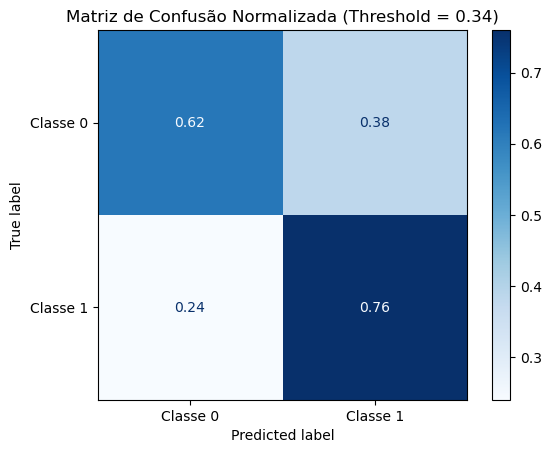

              precision    recall  f1-score   support

           0     0.9589    0.6165    0.7505      3784
           1     0.1788    0.7596    0.2895       416

    accuracy                         0.6307      4200
   macro avg     0.5689    0.6881    0.5200      4200
weighted avg     0.8816    0.6307    0.7049      4200



In [32]:
probs_teste = rf_wo_smote_todos_anos.predict_proba(X_teste.drop(columns=['NU_ANO']))[:, 1]

plot_confusion_matrix_normalizada_com_metricas(y_teste, probs_teste, threshold=0.34)

Considerando o desbalanceamento de classes (apenas 416 instâncias da Classe 1 em 4200 no total), atingir 75% de `recall` é um feito importante. Isso demonstra que o modelo é eficaz em identificar a maioria das ocorrências da classe de interesse, o que é fundamental em cenários onde perder um caso positivo tem um custo alto. A pequena diferença em relação ao 0.8 pode ser ajustada com um refinamento mínimo no `threshold`, se necessário, mas o patamar atual já indica um bom desempenho na detecção.

Agora iremos salvar o modelo acima na pasta de dados `data/rf_wo_smote_todos_anos.joblib`, junto da repartição dos datasets de treino e teste por colunas alvo, para enfim seguirmos para o Lab 03 de Fairness

In [ ]:
import joblib
import pandas as pd
import os

output_dir = 'data'
os.makedirs(output_dir, exist_ok=True)

model_filepath_1 = os.path.join(output_dir, 'rf_wo_smote_todos_anos.joblib')
joblib.dump(rf_wo_smote_todos_anos, model_filepath_1)

model_filepath_2 = os.path.join(output_dir, 'rf_wo_smote_sem_ultimo_ano.joblib')
joblib.dump(rf_wo_smote_ultimo_ano, model_filepath_2)

X_teste_filepath = os.path.join(output_dir, 'df_treino.parquet')
df_treino.to_parquet(X_teste_filepath, index=False) 

X_teste_filepath = os.path.join(output_dir, 'df_teste.parquet')
df_teste.to_parquet(X_teste_filepath, index=False) 

X_teste_filepath = os.path.join(output_dir, 'X_teste.parquet')
X_teste.to_parquet(X_teste_filepath, index=False) 

X_treino_filepath = os.path.join(output_dir, 'X_treino.parquet')
X_treino.to_parquet(X_treino_filepath, index=False)

X_val_filepath = os.path.join(output_dir, 'X_val.parquet')
X_val.to_parquet(X_val_filepath, index=False)

y_teste_filepath = os.path.join(output_dir, 'y_teste.parquet')
y_teste.to_frame(name='target').to_parquet(y_teste_filepath, index=False)

y_treino_filepath = os.path.join(output_dir, 'y_treino.parquet')
y_treino.to_frame(name='target').to_parquet(y_treino_filepath, index=False)

y_val_filepath = os.path.join(output_dir, 'y_val.parquet')
y_val.to_frame(name='target').to_parquet(y_val_filepath, index=False)